road_df  :    115 sensor stations
align_df :  51152 station-incident pairs
haz_df   :  51152 hazard records  (22 types)

Graph built:
  Nodes      : 115
  Edges      : 436 (same-road 198 + spatial-kNN 238)
  Components : 18, giant = 67 nodes

Saved: node_order_nsw.npy (115 nodes)
Saved: adj_matrix_nsw.npy (115, 115)

Computing centrality metrics …

Top-10 stations by composite centrality:
 rank station_id          road_name           suburb  degree_cent  between_cent  close_cent  composite_score  incident_count
    1       9658 Pennant Hills Road         Oatlands     0.075758      0.312354    0.052703         0.785042             127
    2   F3FWY001   Pacific Motorway  North Wahroonga     0.136364      0.145455    0.046873         0.743310              44
    3    9836-PR      Victoria Road             Ryde     0.090909      0.201399    0.055341         0.738735             106
    4      74230 Pennant Hills Road       Thornleigh     0.090909      0.225175    0.052176         0.734735

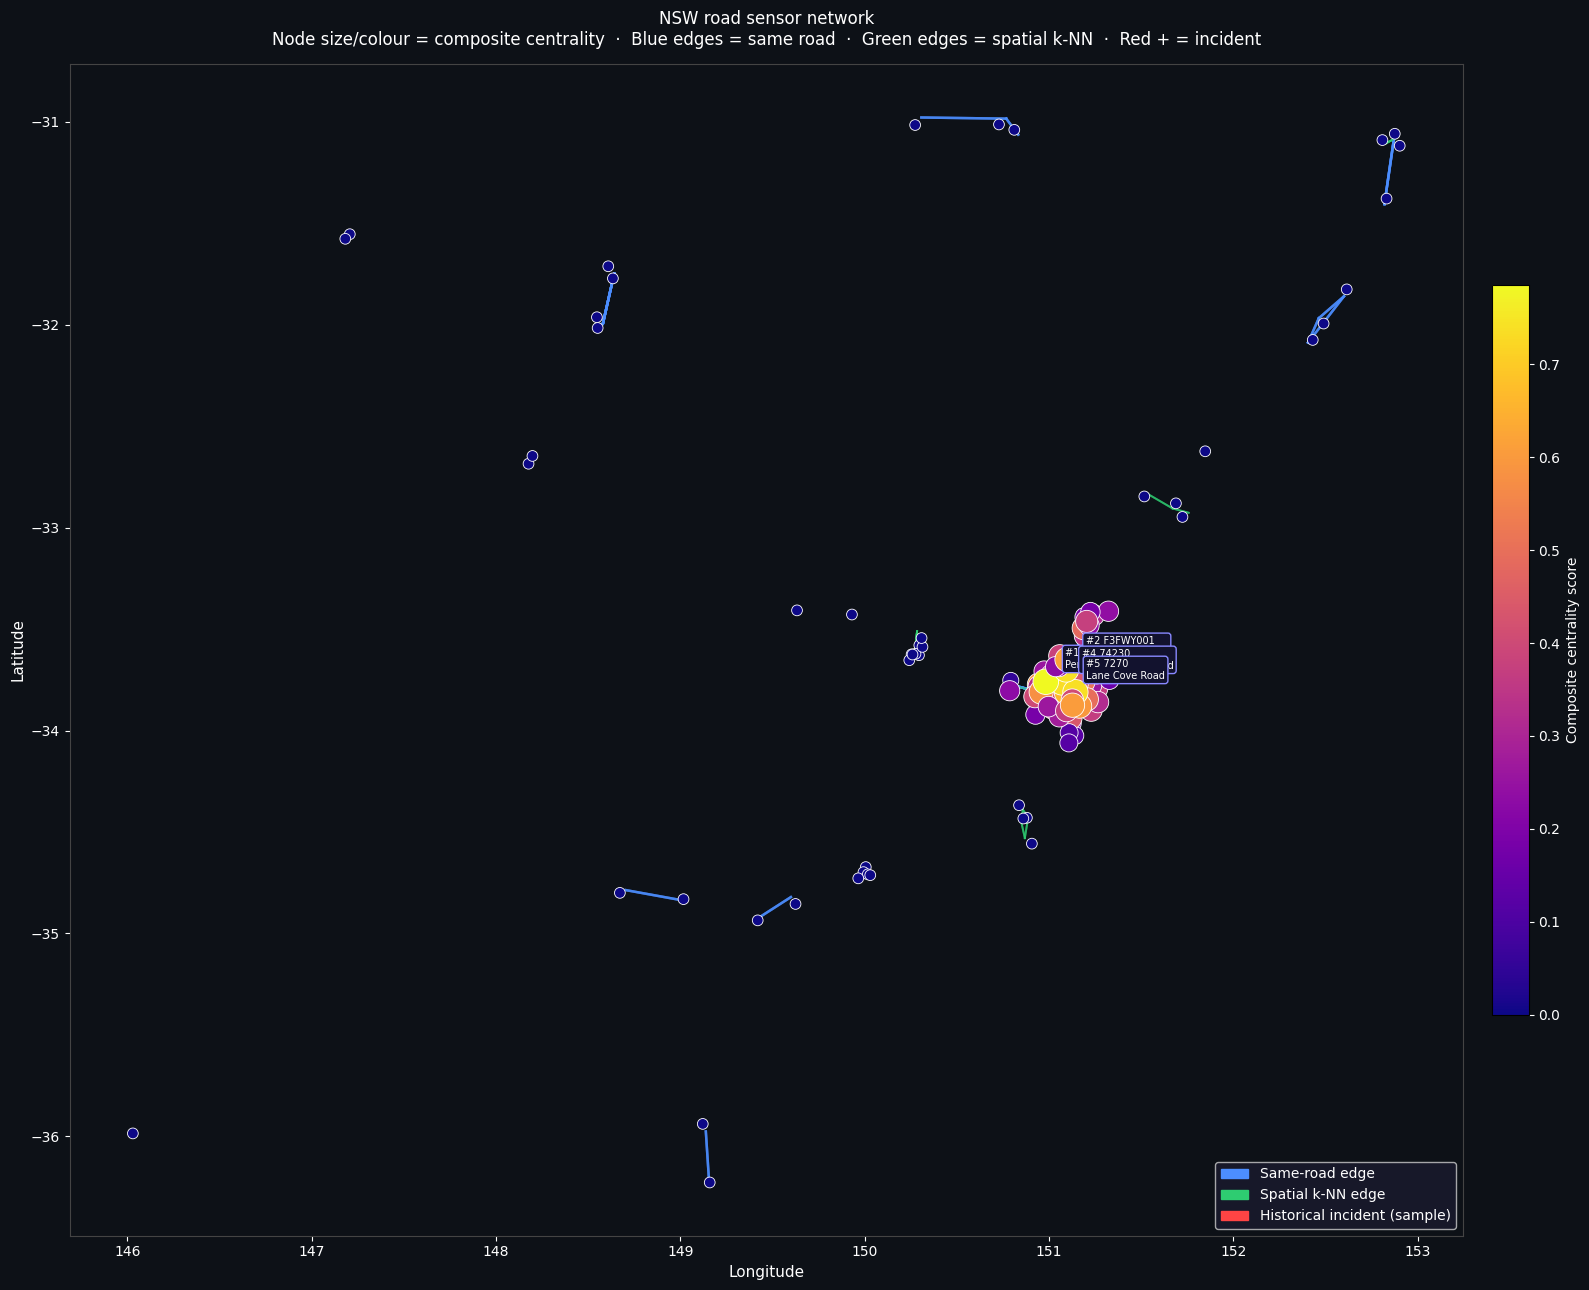

  → fig1_road_network.png
Figure 2: centrality comparison bar chart …


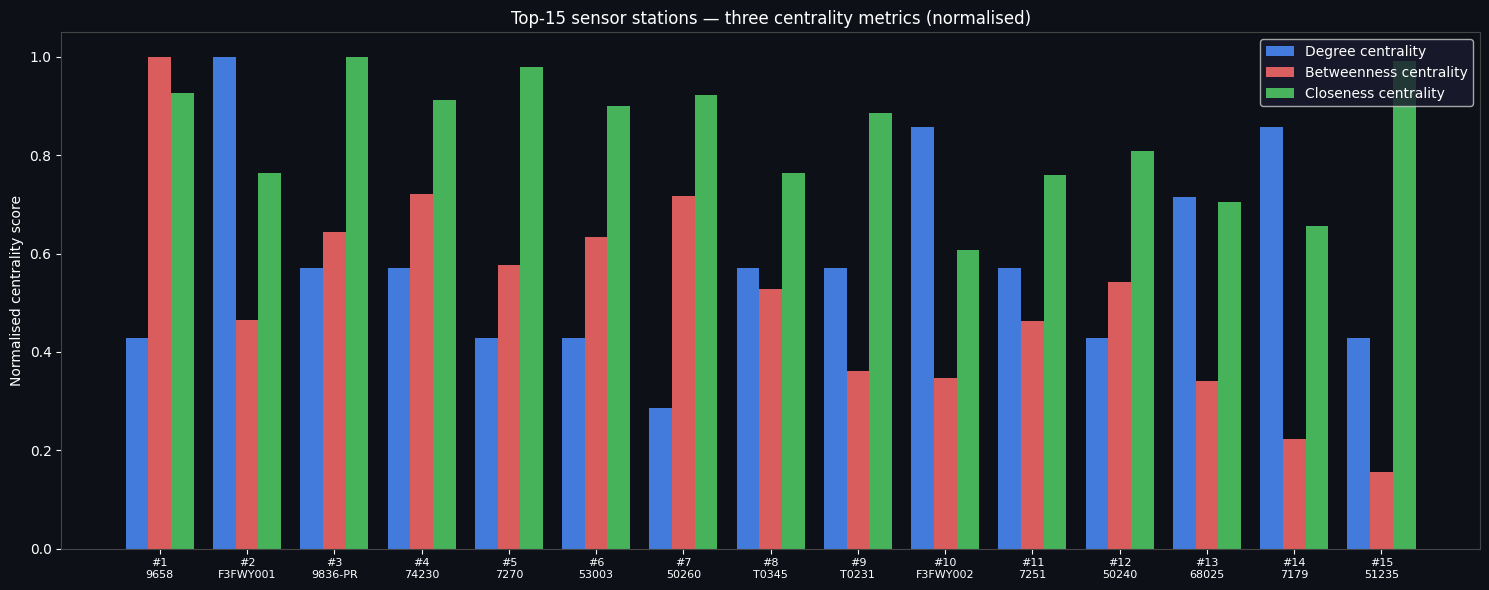

  → fig2_centrality_comparison.png
Figure 3: centrality vs incident count scatter …


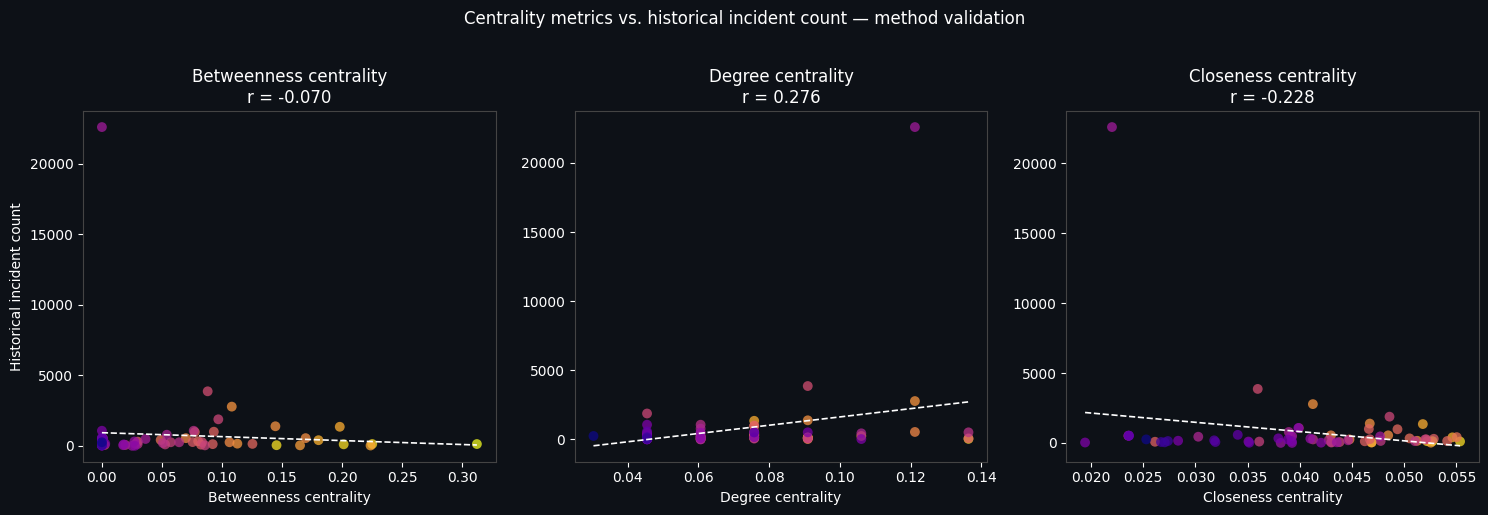

  → fig3_centrality_vs_incidents.png
Figure 4: historical incident distribution …


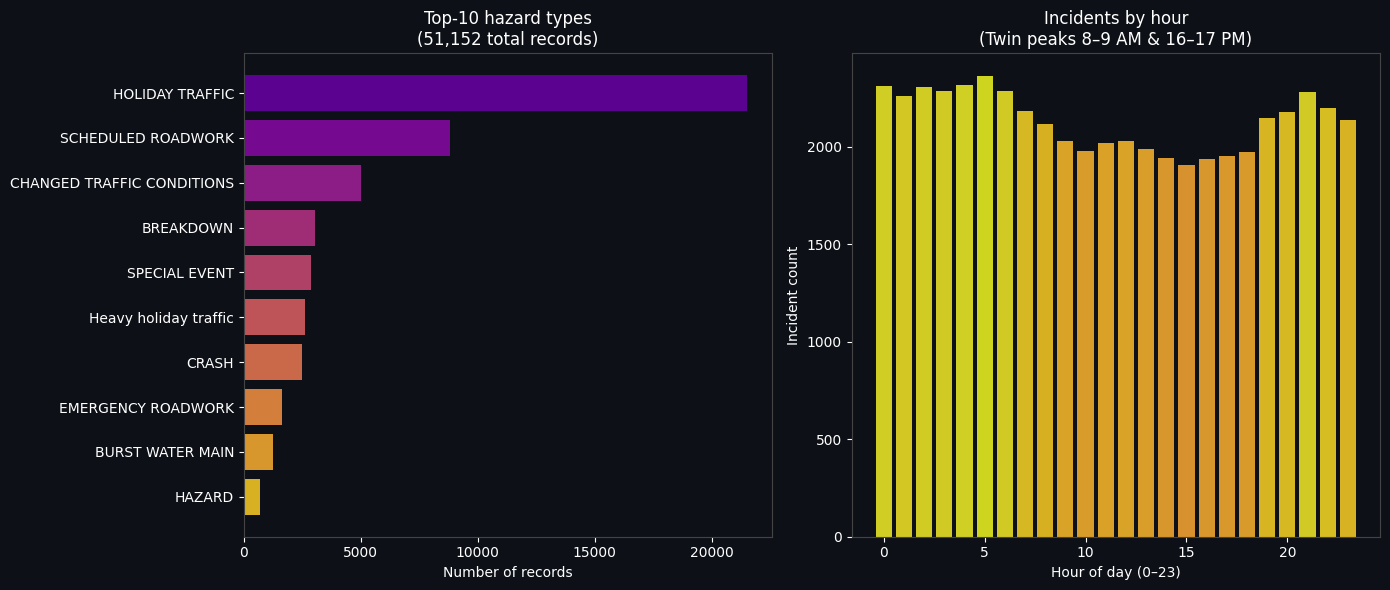

  → fig4_incident_distribution.png

Exported: centrality_rankings.csv
Exported: graph_summary.json

  Member 3 — Road Network Graph & Centrality Analysis

Network  : 115 nodes / 436 edges
           Giant component = 67 nodes

Top-5 most critical stations (composite centrality):
  #1  9658             Pennant Hills Road                   score=0.7850  incidents=127
  #2  F3FWY001         Pacific Motorway                     score=0.7433  incidents=44
  #3  9836-PR          Victoria Road                        score=0.7387  incidents=106
  #4  74230            Pennant Hills Road                   score=0.7347  incidents=129
  #5  7270             Lane Cove Road                       score=0.6619  incidents=400

Figures saved:
  fig1_*.png  — Road network map (node size = centrality, incident overlay)
  fig2_*.png  — Top-15 centrality comparison (3-metric grouped bar)
  fig3_*.png  — Centrality vs. incident count (validation scatter)
  fig4_*.png  — Historical incident types & hourly dis

In [3]:
"""
=============================================================================
DATA5925 Group 14 — Member 3: Spatial Graph & Centrality Analysis
=============================================================================

=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0.  Imports & data loading
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import json, os

road_df  = pd.read_csv("roaddetail_2025.csv")
road_df["station_id"] = road_df["station_id"].astype(str).str.strip()
road_df  = road_df.dropna(subset=["wgs84_latitude", "wgs84_longitude"])

align_df = pd.read_csv("final_incidents_with_weather.csv", low_memory=False)
align_df["station_id"] = align_df["station_id"].astype(str).str.strip()
align_df["dt"] = pd.to_datetime(align_df["match_hour"], errors="coerce")

haz_df   = pd.read_csv("final_incidents_with_weather.csv")
haz_df = haz_df.rename(columns={"Abs PM_x": "latitude", "Abs PM_y": "longitude"})
haz_df["dt"] = pd.to_datetime(haz_df["match_hour"], errors="coerce")

print(f"road_df  : {len(road_df):>6} sensor stations")
print(f"align_df : {len(align_df):>6} station-incident pairs")
print(f"haz_df   : {len(haz_df):>6} hazard records  ({haz_df['hazard_type'].nunique()} types)")

# ─────────────────────────────────────────────────────────────────────────────
# 1.  Shared helpers
# ─────────────────────────────────────────────────────────────────────────────
BG_COLOR = "#0d1117"

def apply_dark_theme(ax):
    """Apply consistent dark background + white axis styling."""
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres (Haversine formula)."""
    R = 6371.0
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = la2 - la1, lo2 - lo1
    a = np.sin(dlat / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def safe_corr(a, b):
    """Pearson r guarded against constant columns (returns nan instead of error)."""
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


# ─────────────────────────────────────────────────────────────────────────────
# 2.  Build road network graph
# ─────────────────────────────────────────────────────────────────────────────
# Strategy A — same-road stations within ROAD_DIST km
# Strategy B — k-NN spatial nearest neighbours within KNN_MAX km

ROAD_DIST = 50.0   # km
KNN_K     = 3
KNN_MAX   = 15.0   # km

ids   = road_df["station_id"].values
roads = road_df["road_name"].values
lats  = road_df["wgs84_latitude"].values
lons  = road_df["wgs84_longitude"].values
n     = len(ids)

# Pre-compute full pairwise distance matrix
D = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        D[i, j] = D[j, i] = haversine_km(lats[i], lons[i], lats[j], lons[j])

G = nx.DiGraph()
for _, row in road_df.iterrows():
    G.add_node(
        row["station_id"],
        lat=row["wgs84_latitude"],
        lon=row["wgs84_longitude"],
        road=str(row["road_name"]),
        suburb=str(row["suburb"]),
        device=str(row["device_type"]),
        quality=int(row["quality_rating"]),
    )

# Strategy A: same-road directed edges
same_road_pairs = 0
for i in range(n):
    for j in range(i + 1, n):
        if roads[i] == roads[j] and D[i, j] <= ROAD_DIST:
            G.add_edge(ids[i], ids[j], weight=D[i, j], etype="same_road")
            G.add_edge(ids[j], ids[i], weight=D[i, j], etype="same_road")
            same_road_pairs += 1

# Strategy B: k-NN spatial edges
knn_pairs = 0
for i in range(n):
    sorted_js = np.argsort(D[i])
    count = 0
    for j in sorted_js:
        if j == i:
            continue
        if D[i, j] > KNN_MAX or count >= KNN_K:
            break
        if not G.has_edge(ids[i], ids[j]):
            G.add_edge(ids[i], ids[j], weight=D[i, j], etype="spatial_knn")
            G.add_edge(ids[j], ids[i], weight=D[i, j], etype="spatial_knn")
            knn_pairs += 1
        count += 1

UG         = G.to_undirected()
components = list(nx.connected_components(UG))
giant      = max(components, key=len)
G_giant    = G.subgraph(giant).copy()
UG_giant   = G_giant.to_undirected()

print(f"\nGraph built:")
print(f"  Nodes      : {G.number_of_nodes()}")
print(f"  Edges      : {G.number_of_edges()} "
      f"(same-road {same_road_pairs*2} + spatial-kNN {knn_pairs*2})")
print(f"  Components : {len(components)}, giant = {len(giant)} nodes")

# Save adjacency matrix and node order
node_order = list(G.nodes())
adj_matrix = nx.to_numpy_array(G, nodelist=node_order, weight="weight")
np.save("node_order_nsw.npy", np.array(node_order))
np.save("adj_matrix_nsw.npy", adj_matrix)
print(f"\nSaved: node_order_nsw.npy ({len(node_order)} nodes)")
print(f"Saved: adj_matrix_nsw.npy {adj_matrix.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# 3.  Centrality metrics
# ─────────────────────────────────────────────────────────────────────────────
print("\nComputing centrality metrics …")
deg_cent = nx.degree_centrality(UG_giant)
bet_cent = nx.betweenness_centrality(UG_giant, normalized=True, weight="weight")
clo_cent = nx.closeness_centrality(UG_giant, distance="weight")

cent_df = pd.DataFrame({
    "station_id"  : list(deg_cent.keys()),
    "degree_cent" : list(deg_cent.values()),
    "between_cent": [bet_cent.get(nd, 0) for nd in deg_cent],
    "close_cent"  : [clo_cent.get(nd, 0) for nd in deg_cent],
})

# Min-max normalise each metric to [0, 1]
for col in ["degree_cent", "between_cent", "close_cent"]:
    mn, mx = cent_df[col].min(), cent_df[col].max()
    cent_df[col + "_norm"] = (cent_df[col] - mn) / (mx - mn + 1e-9)

# Composite score = equal-weight average of the three normalised metrics
cent_df["composite_score"] = cent_df[
    ["degree_cent_norm", "between_cent_norm", "close_cent_norm"]
].mean(axis=1)

cent_df = cent_df.sort_values("composite_score", ascending=False).reset_index(drop=True)
cent_df["rank"] = cent_df.index + 1

# Merge road metadata
cent_df = cent_df.merge(
    road_df[["station_id", "road_name", "suburb",
             "wgs84_latitude", "wgs84_longitude"]],
    on="station_id", how="left",
)

# Merge incident counts
inc_cnt = (align_df
    .groupby("station_id")
    .size()
    .reset_index(name="incident_count"))
cent_df = cent_df.merge(inc_cnt, on="station_id", how="left")
cent_df["incident_count"] = cent_df["incident_count"].fillna(0).astype(int)

print("\nTop-10 stations by composite centrality:")
show = ["rank", "station_id", "road_name", "suburb",
        "degree_cent", "between_cent", "close_cent",
        "composite_score", "incident_count"]
print(cent_df[show].head(10).to_string(index=False))

# Pearson correlation: centrality vs. historical incident counts
r_between = safe_corr(cent_df["between_cent"], cent_df["incident_count"])
r_degree  = safe_corr(cent_df["degree_cent"],  cent_df["incident_count"])
r_close   = safe_corr(cent_df["close_cent"],   cent_df["incident_count"])
print(f"\nValidation (centrality vs incident count):")
print(f"  Betweenness r = {r_between:.3f}")
print(f"  Degree      r = {r_degree:.3f}")
print(f"  Closeness   r = {r_close:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# 4.  Figure 1 — Road network map
# ─────────────────────────────────────────────────────────────────────────────
# ─── Figure 1 — Road Network Map (improved) ───────────────────────────────
print("\nFigure 1: road network map …")

node_list = list(G.nodes())
lons_all  = [G.nodes[nd]["lon"] for nd in node_list]
lats_all  = [G.nodes[nd]["lat"] for nd in node_list]

score_map = dict(zip(cent_df["station_id"], cent_df["composite_score"]))
scores    = np.array([score_map.get(nd, 0.0) for nd in node_list])
norm      = mcolors.Normalize(vmin=scores.min(), vmax=scores.max())

fig, ax = plt.subplots(figsize=(16, 13))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# ── Edges: thicker and brighter colours ──────────────────────────────────
for u, v, d in G.edges(data=True):
    if d.get("etype") == "same_road":
        col, lw, alpha = "#4c8eff", 1.8, 0.75   # bright blue, thicker
    else:
        col, lw, alpha = "#2ecc71", 1.4, 0.65   # bright green, thicker
    ax.plot(
        [G.nodes[u]["lon"], G.nodes[v]["lon"]],
        [G.nodes[u]["lat"], G.nodes[v]["lat"]],
        color=col, lw=lw, alpha=alpha, zorder=1,
    )

# ── Nodes: add jitter to separate overlapping points ─────────────────────
rng    = np.random.RandomState(99)
jitter = 0.04   # degrees — small enough to stay geographically accurate
lons_j = np.array(lons_all) + rng.uniform(-jitter, jitter, len(lons_all))
lats_j = np.array(lats_all) + rng.uniform(-jitter, jitter, len(lats_all))

# Node size: log scale so clustered nodes don't all become huge
sizes = 60 + 280 * np.sqrt(norm(scores))   # sqrt spreads the size range

sc = ax.scatter(
    lons_j, lats_j,
    c=scores, cmap=cm.plasma, norm=norm,
    s=sizes,
    edgecolors="white", linewidths=0.6, zorder=3,
)

# ── Historical incidents ──────────────────────────────────────────────────
haz_geo = haz_df.dropna(subset=["latitude", "longitude"])
haz_s   = haz_geo.sample(min(400, len(haz_geo)), random_state=42)
ax.scatter(
    haz_s["longitude"], haz_s["latitude"],
    c="#ff4444", marker="+", s=22, alpha=0.45, lw=1.2,
    zorder=2, label="Historical incident (sample)",
)

# ── Annotate top-5 ────────────────────────────────────────────────────────
for idx, (_, row) in enumerate(cent_df.head(5).iterrows()):
    if pd.notna(row.get("wgs84_longitude")):
        # use jittered position of this node
        ni = node_list.index(row["station_id"]) if row["station_id"] in node_list else None
        xp = lons_j[ni] if ni is not None else row["wgs84_longitude"]
        yp = lats_j[ni] if ni is not None else row["wgs84_latitude"]
        ax.annotate(
            f"#{int(row['rank'])} {row['station_id']}\n{str(row['road_name'])[:22]}",
            xy=(xp, yp),
            xytext=(14, 10), textcoords="offset points",
            color="white", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", fc="#12122e", ec="#8888ff", lw=1.0),
            zorder=6,
        )

# ── Colorbar ──────────────────────────────────────────────────────────────
cb = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("Composite centrality score", color="white", fontsize=10)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

# ── Legend ────────────────────────────────────────────────────────────────
p_road = mpatches.Patch(color="#4c8eff", label="Same-road edge")
p_knn  = mpatches.Patch(color="#2ecc71", label="Spatial k-NN edge")
p_haz  = mpatches.Patch(color="#ff4444", label="Historical incident (sample)")
ax.legend(handles=[p_road, p_knn, p_haz],
          loc="lower right", facecolor="#1a1a2e",
          labelcolor="white", fontsize=10)

apply_dark_theme(ax)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.set_title(
    "NSW road sensor network\n"
    "Node size/colour = composite centrality  ·  "
    "Blue edges = same road  ·  Green edges = spatial k-NN  ·  Red + = incident",
    fontsize=12, pad=14,
)

plt.tight_layout()
plt.savefig("fig1_road_network.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("  → fig1_road_network.png")


# ─────────────────────────────────────────────────────────────────────────────
# 5.  Figure 2 — Centrality comparison: Top-15 stations, grouped bar
# ─────────────────────────────────────────────────────────────────────────────
print("Figure 2: centrality comparison bar chart …")

top15  = cent_df.head(15).copy()
labels = [f"#{int(r)}\n{sid}"
          for r, sid in zip(top15["rank"], top15["station_id"])]
x, w   = np.arange(len(labels)), 0.26

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(BG_COLOR)

ax.bar(x - w, top15["degree_cent_norm"],  w,
       label="Degree centrality",      color="#4c8eff", alpha=0.85)
ax.bar(x,     top15["between_cent_norm"], w,
       label="Betweenness centrality", color="#ff6b6b", alpha=0.85)
ax.bar(x + w, top15["close_cent_norm"],   w,
       label="Closeness centrality",   color="#51cf66", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, color="white", fontsize=8)
ax.set_ylabel("Normalised centrality score")
ax.set_title("Top-15 sensor stations — three centrality metrics (normalised)")
apply_dark_theme(ax)
ax.legend(facecolor="#1a1a2e", labelcolor="white")

plt.tight_layout()
plt.savefig("fig2_centrality_comparison.png", dpi=150, bbox_inches="tight",
            facecolor=BG_COLOR)
plt.show()
print("  → fig2_centrality_comparison.png")


# ─────────────────────────────────────────────────────────────────────────────
# 6.  Figure 3 — Centrality vs. historical incident count (validation)
# ─────────────────────────────────────────────────────────────────────────────
print("Figure 3: centrality vs incident count scatter …")

pairs = [
    ("between_cent", "Betweenness centrality", f"r = {r_between:.3f}"),
    ("degree_cent",  "Degree centrality",      f"r = {r_degree:.3f}"),
    ("close_cent",   "Closeness centrality",   f"r = {r_close:.3f}"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG_COLOR)
rng = np.random.RandomState(42)

for ax, (col, label, r_str) in zip(axes, pairs):
    jitter = rng.uniform(-0.3, 0.3, len(cent_df))
    ax.scatter(
        cent_df[col],
        cent_df["incident_count"] + jitter,
        c=cent_df["composite_score"], cmap="plasma",
        alpha=0.75, s=50, edgecolors="none",
    )
    x_arr = cent_df[col].values
    y_arr = cent_df["incident_count"].values
    if x_arr.std() > 1e-9:
        m = np.cov(x_arr, y_arr)[0, 1] / (np.var(x_arr) + 1e-9)
        b = y_arr.mean() - m * x_arr.mean()
        xs = np.linspace(x_arr.min(), x_arr.max(), 60)
        ax.plot(xs, m * xs + b, "w--", lw=1.2, label="Regression")

    apply_dark_theme(ax)
    ax.set_xlabel(label)
    ax.set_ylabel("Historical incident count" if ax is axes[0] else "")
    ax.set_title(f"{label}\n{r_str}")

fig.suptitle("Centrality metrics vs. historical incident count — method validation",
             color="white", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig3_centrality_vs_incidents.png", dpi=150, bbox_inches="tight",
            facecolor=BG_COLOR)
plt.show()
print("  → fig3_centrality_vs_incidents.png")


# ─────────────────────────────────────────────────────────────────────────────
# 7.  Figure 4 — Historical hazard distribution
# ─────────────────────────────────────────────────────────────────────────────
print("Figure 4: historical incident distribution …")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)

# Top-10 hazard types
top_types  = haz_df["hazard_type"].value_counts().head(10)
bar_colors = cm.plasma(np.linspace(0.2, 0.9, len(top_types)))
ax1.barh(top_types.index[::-1], top_types.values[::-1],
         color=bar_colors[::-1], alpha=0.85)
ax1.set_xlabel("Number of records")
ax1.set_title(f"Top-10 hazard types\n({len(haz_df):,} total records)")
apply_dark_theme(ax1)

# Hourly distribution
haz_valid = haz_df.dropna(subset=["dt"])
hour_cnt  = haz_valid["dt"].dt.hour.value_counts().sort_index()
ax2.bar(
    hour_cnt.index, hour_cnt.values,
    color=cm.plasma(hour_cnt.values / hour_cnt.values.max()),
    alpha=0.85,
)
ax2.set_xlabel("Hour of day (0–23)")
ax2.set_ylabel("Incident count")
ax2.set_title("Incidents by hour\n(Twin peaks 8–9 AM & 16–17 PM)")
apply_dark_theme(ax2)

plt.tight_layout()
plt.savefig("fig4_incident_distribution.png", dpi=150, bbox_inches="tight",
            facecolor=BG_COLOR)
plt.show()
print("  → fig4_incident_distribution.png")


# ─────────────────────────────────────────────────────────────────────────────
# 8.  Export result tables
# ─────────────────────────────────────────────────────────────────────────────
cent_df.to_csv("centrality_rankings.csv", index=False)
print("\nExported: centrality_rankings.csv")

summary = {
    "graph_nodes"              : G.number_of_nodes(),
    "graph_edges"              : G.number_of_edges(),
    "giant_component_nodes"    : len(giant),
    "n_connected_components"   : len(components),
    "dist_threshold_same_road_km": ROAD_DIST,
    "knn_k"                    : KNN_K,
    "knn_max_km"               : KNN_MAX,
    "corr_betweenness_incidents": round(r_between, 4) if not np.isnan(r_between) else None,
    "corr_degree_incidents"    : round(r_degree, 4)   if not np.isnan(r_degree)  else None,
    "corr_closeness_incidents" : round(r_close, 4)    if not np.isnan(r_close)   else None,
}
with open("graph_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Exported: graph_summary.json")


# ─────────────────────────────────────────────────────────────────────────────
# 9.  Summary
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  Member 3 — Road Network Graph & Centrality Analysis")
print("=" * 65)
print(f"\nNetwork  : {G.number_of_nodes()} nodes / {G.number_of_edges()} edges")
print(f"           Giant component = {len(giant)} nodes")
print(f"\nTop-5 most critical stations (composite centrality):")
for _, row in cent_df.head(5).iterrows():
    print(f"  #{int(row['rank'])}  {row['station_id']:15s}  "
          f"{str(row['road_name'])[:35]:35s}  "
          f"score={row['composite_score']:.4f}  "
          f"incidents={int(row['incident_count'])}")
print(f"\nFigures saved:")
for i, desc in enumerate([
    "Road network map (node size = centrality, incident overlay)",
    "Top-15 centrality comparison (3-metric grouped bar)",
    "Centrality vs. incident count (validation scatter)",
    "Historical incident types & hourly distribution",
], 1):
    print(f"  fig{i}_*.png  — {desc}")
print(f"\nFiles saved:")
print(f"  node_order_nsw.npy      — {len(node_order)} station IDs in fixed order")
print(f"  adj_matrix_nsw.npy      — {adj_matrix.shape} adjacency matrix")
print(f"  centrality_rankings.csv — centrality scores for all stations")
print(f"  graph_summary.json      — graph statistics")

In [5]:
import base64, os

figs = [
    ("fig1_road_network.png",            "Figure 1 — Road Network Map"),
    ("fig2_centrality_comparison.png",   "Figure 2 — Centrality Comparison"),
    ("fig3_centrality_vs_incidents.png", "Figure 3 — Centrality vs. Incident Count"),
    ("fig4_incident_distribution.png",   "Figure 4 — Historical Incident Distribution"),
]

html = """<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Member 3 — Results</title>
<style>
  body  { background:#0d1117; color:#c9d1d9; font-family:Arial,sans-serif;
          max-width:1100px; margin:0 auto; padding:40px 24px; }
  h1    { color:#4c8eff; border-bottom:2px solid #4c8eff; padding-bottom:10px; }
  h2    { color:#a8b5cc; margin-top:50px; border-left:4px solid #4c8eff;
          padding-left:12px; }
  p     { color:#8b949e; line-height:1.7; }
  img   { width:100%; border-radius:8px; margin:16px 0 40px;
          border:1px solid #21262d; }
  .meta { color:#555; font-size:13px; margin-bottom:40px; }
  hr    { border:none; border-top:1px solid #21262d; margin:50px 0; }
</style>
</head>
<body>
<h1>DATA5925 Group 14 — Member 3</h1>
<p class="meta">Xinyue Zhang &nbsp;·&nbsp; z5546556 &nbsp;·&nbsp; June 2026</p>
<hr>
"""

for fname, title in figs:
    if os.path.exists(fname):
        with open(fname, "rb") as f:
            b64 = base64.b64encode(f.read()).decode()
        html += f'<h2>{title}</h2>\n'
        html += f'<img src="data:image/png;base64,{b64}" alt="{title}">\n'
    else:
        html += f'<h2>{title}</h2>\n'
        html += f'<p style="color:#f85149">File not found: {fname}</p>\n'

html += """
<hr>
<p class="meta">Generated by DATA5925 Group 14 · Member 3</p>
</body>
</html>"""

with open("member3_results.html", "w", encoding="utf-8") as f:
    f.write(html)

print(f"Done! Size: {os.path.getsize('member3_results.html')/1024:.1f} KB")

from google.colab import files
files.download("member3_results.html")

Done! Size: 595.3 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import numpy as np
import pandas as pd
import networkx as nx


# ─────────────────────────────────────────────────────────────────────────────
# 1. Full 115-station binary adjacency matrix
#    Convert the km-weighted matrix to 0/1:
#    1 = there is a connection, 0 = no connection
# ─────────────────────────────────────────────────────────────────────────────
adj_matrix_binary = (adj_matrix > 0).astype(float)

np.save("adj_matrix_nsw_binary.npy", adj_matrix_binary)
print(f"Saved: adj_matrix_nsw_binary.npy  shape={adj_matrix_binary.shape}")
print(f"  Total edges (one direction): {int(adj_matrix_binary.sum())}")


# ─────────────────────────────────────────────────────────────────────────────
# 2. Extract the 67-station subgraph
#    Load the flow data to get the list of 67 station IDs that have
#    traffic flow records. These are the stations used in Tasks 1, 3, 4.
# ─────────────────────────────────────────────────────────────────────────────
flow_df = pd.read_csv("final_hourly_flow_allfeature.csv", low_memory=False)

# Standardise station_id format — remove whitespace and convert to string
# (the file has mixed int/str types for the same station)
flow_df["station_id"] = flow_df["station_id"].astype(str).str.strip()

# Get the unique station IDs that have flow data
flow_station_ids = sorted(flow_df["station_id"].unique().tolist())
print(f"\nStation IDs with flow data: {len(flow_station_ids)}")

# Keep only the IDs that also exist in our 115-station graph
# (some flow stations might not be in the road graph)
node_order_str = [str(n).strip() for n in node_order]
station_ids_67 = [sid for sid in flow_station_ids if sid in node_order_str]
print(f"Station IDs present in both flow data and graph: {len(station_ids_67)}")
print(f"First 5: {station_ids_67[:5]}")


# ─────────────────────────────────────────────────────────────────────────────
# 3. Build subgraph and generate node order for 67 stations
#    Extract the subgraph from the full 115-station graph using only
#    the 67 station IDs that have flow data.
# ─────────────────────────────────────────────────────────────────────────────
# Convert node order to string for consistent matching
G_str = nx.relabel_nodes(G, {n: str(n).strip() for n in G.nodes()})

# Extract the subgraph — only keep nodes that are in station_ids_67
G_67 = G_str.subgraph(station_ids_67).copy()

# Save the node order for the 67-station subgraph
# IMPORTANT: everyone must use this same node order file so that
# the adjacency matrix rows/columns align with the flow data matrix
node_order_67 = list(G_67.nodes())
np.save("node_order_67.npy", np.array(node_order_67))
print(f"\nSaved: node_order_67.npy  ({len(node_order_67)} stations)")
print(f"First 5: {node_order_67[:5]}")


# ─────────────────────────────────────────────────────────────────────────────
# 4. 67-station adjacency matrix in km
#    Edge weight = Haversine distance in km between the two stations.
#    0 = no connection.
# ─────────────────────────────────────────────────────────────────────────────
adj_matrix_67 = nx.to_numpy_array(G_67, nodelist=node_order_67, weight="weight")

np.save("adj_matrix_67.npy", adj_matrix_67)
print(f"\nSaved: adj_matrix_67.npy  shape={adj_matrix_67.shape}")
print(f"  Non-zero entries: {int((adj_matrix_67 > 0).sum())}")


# ─────────────────────────────────────────────────────────────────────────────
# 5. 67-station binary adjacency matrix
#    1 = connected, 0 = not connected.
#    Used for causal analysis (Tasks 3 and 4) where we only need to know
#    whether two stations are neighbours, not how far apart they are.
# ─────────────────────────────────────────────────────────────────────────────
adj_matrix_67_binary = (adj_matrix_67 > 0).astype(float)

np.save("adj_matrix_67_binary.npy", adj_matrix_67_binary)
print(f"Saved: adj_matrix_67_binary.npy  shape={adj_matrix_67_binary.shape}")
print(f"  Total connections (one direction): {int(adj_matrix_67_binary.sum())}")


# ─────────────────────────────────────────────────────────────────────────────
# 6. Verification — print a quick summary of all four output files
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  Output files summary")
print("=" * 55)
print(f"  adj_matrix_nsw_binary.npy  — {adj_matrix_binary.shape}  binary  (full 115 stations)")
print(f"  adj_matrix_67.npy          — {adj_matrix_67.shape}    km       (67 flow stations)")
print(f"  adj_matrix_67_binary.npy   — {adj_matrix_67_binary.shape}    binary  (67 flow stations)")
print(f"  node_order_67.npy          — {len(node_order_67)} station IDs in fixed order")


# ─────────────────────────────────────────────────────────────────────────────
# 7. Download all files
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files

files.download("adj_matrix_nsw_binary.npy")
files.download("adj_matrix_67.npy")
files.download("adj_matrix_67_binary.npy")
files.download("node_order_67.npy")

print("\nAll files downloaded.")

Saved: adj_matrix_nsw_binary.npy  shape=(115, 115)
  Total edges (one direction): 436

Station IDs with flow data: 67
Station IDs present in both flow data and graph: 67
First 5: ['100001', '10011', '22001', '23067', '29005']

Saved: node_order_67.npy  (67 stations)
First 5: ['100001', '10011', '22001', '23067', '29005']

Saved: adj_matrix_67.npy  shape=(67, 67)
  Non-zero entries: 314
Saved: adj_matrix_67_binary.npy  shape=(67, 67)
  Total connections (one direction): 314

  Output files summary
  adj_matrix_nsw_binary.npy  — (115, 115)  binary  (full 115 stations)
  adj_matrix_67.npy          — (67, 67)    km       (67 flow stations)
  adj_matrix_67_binary.npy   — (67, 67)    binary  (67 flow stations)
  node_order_67.npy          — 67 station IDs in fixed order


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded.


In [10]:
import numpy as np
import pandas as pd

# ── Load all five files ───────────────────────────────────────────
node_order    = np.load("node_order_nsw.npy",       allow_pickle=True)
node_order_67 = np.load("node_order_67.npy",        allow_pickle=True)
adj_km        = np.load("adj_matrix_nsw.npy")
adj_binary    = np.load("adj_matrix_nsw_binary.npy")
adj_67        = np.load("adj_matrix_67.npy")
adj_67_binary = np.load("adj_matrix_67_binary.npy")

# ── 1. adj_matrix_nsw (km) ───────────────────────────────────────
print("=" * 55)
print("adj_matrix_nsw.npy  (115 x 115, km)")
print("=" * 55)
print(f"Shape        : {adj_km.shape}")
print(f"Max distance : {adj_km.max():.2f} km")
print(f"Non-zero     : {int((adj_km > 0).sum())} entries")
print(f"Unique values: contains distances in km")
df0 = pd.DataFrame(adj_km[:8, :8].round(2),
                   index=node_order[:8],
                   columns=node_order[:8])
print("\nTop-left 8x8 corner (km):")
print(df0)

# ── 2. adj_matrix_nsw_binary ─────────────────────────────────────
print("\n" + "=" * 55)
print("adj_matrix_nsw_binary.npy  (115 x 115, 0/1)")
print("=" * 55)
print(f"Shape        : {adj_binary.shape}")
print(f"Total edges  : {int(adj_binary.sum())}")
print(f"Unique values: {np.unique(adj_binary)}")
df1 = pd.DataFrame(adj_binary[:8, :8].astype(int),
                   index=node_order[:8],
                   columns=node_order[:8])
print("\nTop-left 8x8 corner (0/1):")
print(df1)

# ── 3. adj_matrix_67 (km) ────────────────────────────────────────
print("\n" + "=" * 55)
print("adj_matrix_67.npy  (67 x 67, km)")
print("=" * 55)
print(f"Shape        : {adj_67.shape}")
print(f"Max distance : {adj_67.max():.2f} km")
print(f"Non-zero     : {int((adj_67 > 0).sum())} entries")
df2 = pd.DataFrame(adj_67[:8, :8].round(2),
                   index=node_order_67[:8],
                   columns=node_order_67[:8])
print("\nTop-left 8x8 corner (km):")
print(df2)

# ── 4. adj_matrix_67_binary ──────────────────────────────────────
print("\n" + "=" * 55)
print("adj_matrix_67_binary.npy  (67 x 67, 0/1)")
print("=" * 55)
print(f"Shape        : {adj_67_binary.shape}")
print(f"Total edges  : {int(adj_67_binary.sum())}")
print(f"Unique values: {np.unique(adj_67_binary)}")
df3 = pd.DataFrame(adj_67_binary[:8, :8].astype(int),
                   index=node_order_67[:8],
                   columns=node_order_67[:8])
print("\nTop-left 8x8 corner (0/1):")
print(df3)

# ── 5. node_order_67 ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("node_order_67.npy")
print("=" * 55)
print(f"Total stations : {len(node_order_67)}")
print(f"All station IDs:\n{node_order_67}")

# ── Summary ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  All files summary")
print("=" * 55)
print(f"  adj_matrix_nsw.npy         {adj_km.shape}   km      (115 stations)")
print(f"  adj_matrix_nsw_binary.npy  {adj_binary.shape}   0/1     (115 stations)")
print(f"  adj_matrix_67.npy          {adj_67.shape}     km      (67 stations)")
print(f"  adj_matrix_67_binary.npy   {adj_67_binary.shape}     0/1     (67 stations)")
print(f"  node_order_nsw.npy         {len(node_order)} station IDs")
print(f"  node_order_67.npy          {len(node_order_67)} station IDs")

adj_matrix_nsw.npy  (115 x 115, km)
Shape        : (115, 115)
Max distance : 43.91 km
Non-zero     : 436 entries
Unique values: contains distances in km

Top-left 8x8 corner (km):
        100001  10011  22001  23067  29005  32029  33014  34016
100001     0.0   0.00   0.00    0.0    0.0   0.00   0.00   0.00
10011      0.0   0.00   5.68    0.0    0.0   0.00   0.00   0.00
22001      0.0   5.68   0.00    0.0    0.0   0.00   5.41   6.13
23067      0.0   0.00   0.00    0.0    0.0   0.00   0.00   0.00
29005      0.0   0.00   0.00    0.0    0.0   0.00   0.00   0.00
32029      0.0   0.00   0.00    0.0    0.0   0.00   3.21   0.00
33014      0.0   0.00   5.41    0.0    0.0   3.21   0.00   0.00
34016      0.0   0.00   6.13    0.0    0.0   0.00   0.00   0.00

adj_matrix_nsw_binary.npy  (115 x 115, 0/1)
Shape        : (115, 115)
Total edges  : 436
Unique values: [0. 1.]

Top-left 8x8 corner (0/1):
        100001  10011  22001  23067  29005  32029  33014  34016
100001       0      0      0      0    

In [6]:
import json

summary = {
    "graph_nodes"               : G.number_of_nodes(),
    "graph_edges"               : G.number_of_edges(),
    "giant_component_nodes"     : len(giant),
    "n_connected_components"    : len(components),
    "dist_threshold_same_road_km": ROAD_DIST,
    "knn_k"                     : KNN_K,
    "knn_max_km"                : KNN_MAX,
    "corr_betweenness_incidents": round(r_between, 4) if not np.isnan(r_between) else None,
    "corr_degree_incidents"     : round(r_degree, 4)  if not np.isnan(r_degree)  else None,
    "corr_closeness_incidents"  : round(r_close, 4)   if not np.isnan(r_close)   else None,
}
with open("graph_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

from google.colab import files
files.download("graph_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>